In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/akshatshaw7/cardiovascular-disease-dataset/health_data.csv


In [2]:
import pandas as pd
import numpy as np

In [3]:
data=pd.read_csv("/kaggle/input/datasets/akshatshaw7/cardiovascular-disease-dataset/health_data.csv")

# # convert data into pandas dataframe 

In [4]:
df=pd.DataFrame(data)

# # cheak data frame like which column contain and how many rows and columns ,what is data type and other essential information for data understanding

In [5]:
df.head()

,Unnamed: 0,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,0.0,18393.0,1,168.0,62.0,110.0,80.0,0,0,0,0,1,0
1,1,1.0,20228.0,0,156.0,85.0,140.0,90.0,2,0,0,0,1,1
2,2,2.0,18857.0,0,165.0,64.0,130.0,70.0,2,0,0,0,0,1
3,3,3.0,17623.0,1,169.0,82.0,150.0,100.0,0,0,0,0,1,1
4,4,4.0,17474.0,0,156.0,56.0,100.0,60.0,0,0,0,0,0,0


In [6]:
df.shape

(70000, 14)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Unnamed: 0   70000 non-null  int64  
 1   id           70000 non-null  float64
 2   age          70000 non-null  float64
 3   gender       70000 non-null  int64  
 4   height       70000 non-null  float64
 5   weight       70000 non-null  float64
 6   ap_hi        70000 non-null  float64
 7   ap_lo        70000 non-null  float64
 8   cholesterol  70000 non-null  int64  
 9   gluc         70000 non-null  int64  
 10  smoke        70000 non-null  int64  
 11  alco         70000 non-null  int64  
 12  active       70000 non-null  int64  
 13  cardio       70000 non-null  int64  
dtypes: float64(6), int64(8)
memory usage: 7.5 MB


In [8]:
df.describe()

,Unnamed: 0,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
count,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000
mean,34999.500000,49972.419900,19468.865814,0.349571,164.359229,74.205690,128.817286,96.630414,0.366871,0.226457,0.088129,0.053771,0.803729,0.499700
std,20207.403759,28851.302323,2467.251667,0.476838,8.210126,14.395757,154.011419,188.472530,0.680250,0.572270,0.283484,0.225568,0.397179,0.500003
min,0.000000,0.000000,10798.000000,0.000000,55.000000,10.000000,-150.000000,-70.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,17499.750000,25006.750000,17664.000000,0.000000,159.000000,65.000000,120.000000,80.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
50%,34999.500000,50001.500000,19703.000000,0.000000,165.000000,72.000000,120.000000,80.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
75%,52499.250000,74889.250000,21327.000000,1.000000,170.000000,82.000000,140.000000,90.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000
max,69999.000000,99999.000000,23713.000000,1.000000,250.000000,200.000000,16020.000000,11000.000000,2.000000,2.000000,1.000000,1.000000,1.000000,1.000000


In [9]:
df.dtypes

Unnamed: 0       int64
id             float64
age            float64
gender           int64
height         float64
weight         float64
ap_hi          float64
ap_lo          float64
cholesterol      int64
gluc             int64
smoke            int64
alco             int64
active           int64
cardio           int64
dtype: object

# # the columns remove for unused in model for example columns 'Unnamed :0' and 'id'  

In [10]:
df.drop(columns=['Unnamed: 0'],inplace=True)

In [11]:
df.drop(columns=['id'],inplace=True)

# # in this dataset age are given day so its convert years

In [12]:
df['age']=df['age']/365

# # cheak or count how many people are heart disease or not and draw a graph using seaborn

In [13]:
df['cardio'].value_counts()

cardio
0    35021
1    34979
Name: count, dtype: int64

<Axes: xlabel='cardio', ylabel='count'>

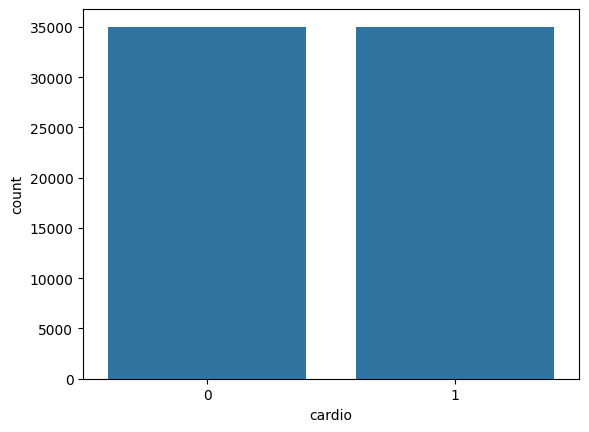

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.countplot(x='cardio', data=df)

In [15]:
df.describe()

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
count,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000
mean,53.339358,0.349571,164.359229,74.205690,128.817286,96.630414,0.366871,0.226457,0.088129,0.053771,0.803729,0.499700
std,6.759594,0.476838,8.210126,14.395757,154.011419,188.472530,0.680250,0.572270,0.283484,0.225568,0.397179,0.500003
min,29.583562,0.000000,55.000000,10.000000,-150.000000,-70.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.394521,0.000000,159.000000,65.000000,120.000000,80.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
50%,53.980822,0.000000,165.000000,72.000000,120.000000,80.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
75%,58.430137,1.000000,170.000000,82.000000,140.000000,90.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000
max,64.967123,1.000000,250.000000,200.000000,16020.000000,11000.000000,2.000000,2.000000,1.000000,1.000000,1.000000,1.000000


# # remove invalid upper and lower bp and weight and hight

In [16]:
df=df[(df['ap_hi'] > 0) & (df['ap_lo'] > 0)]
df=df[(df['ap_hi'] < 250) & (df['ap_lo'] < 200)]

In [17]:
df = df[(df['height'] > 100) & (df['height'] < 220)]
df = df[(df['weight'] > 30) & (df['weight'] < 200)]

# # create a BMI name columns 

In [18]:
df['BMI'] = df['weight'] / ((df['height']/100)**2)

# # again cheak mean ,meadian,std im data set 

In [19]:
df.describe()

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,BMI
count,68941.000000,68941.000000,68941.000000,68941.000000,68941.000000,68941.000000,68941.000000,68941.000000,68941.000000,68941.000000,68941.000000,68941.000000,68941.000000
mean,53.326526,0.348675,164.400241,74.119071,126.331211,81.352997,0.364486,0.225990,0.087858,0.053597,0.803281,0.494945,27.470550
std,6.761338,0.476554,7.964701,14.285790,17.689155,9.801248,0.678755,0.571937,0.283090,0.225221,0.397521,0.499978,5.338163
min,29.583562,0.000000,104.000000,31.000000,7.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,10.726644
25%,48.375342,0.000000,159.000000,65.000000,120.000000,80.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,23.875115
50%,53.975342,0.000000,165.000000,72.000000,120.000000,80.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,26.346494
75%,58.419178,1.000000,170.000000,82.000000,140.000000,90.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,30.119376
max,64.967123,1.000000,207.000000,183.000000,240.000000,190.000000,2.000000,2.000000,1.000000,1.000000,1.000000,1.000000,152.551775


# # cheak again columns name and values 

In [20]:
df.head()

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,BMI
0,50.391781,1,168.0,62.0,110.0,80.0,0,0,0,0,1,0,21.967120
1,55.419178,0,156.0,85.0,140.0,90.0,2,0,0,0,1,1,34.927679
2,51.663014,0,165.0,64.0,130.0,70.0,2,0,0,0,0,1,23.507805
3,48.282192,1,169.0,82.0,150.0,100.0,0,0,0,0,1,1,28.710479
4,47.873973,0,156.0,56.0,100.0,60.0,0,0,0,0,0,0,23.011177


# #sns.countplot() is a Seaborn function used to visualize the count (frequency) of values in a cardio column. 

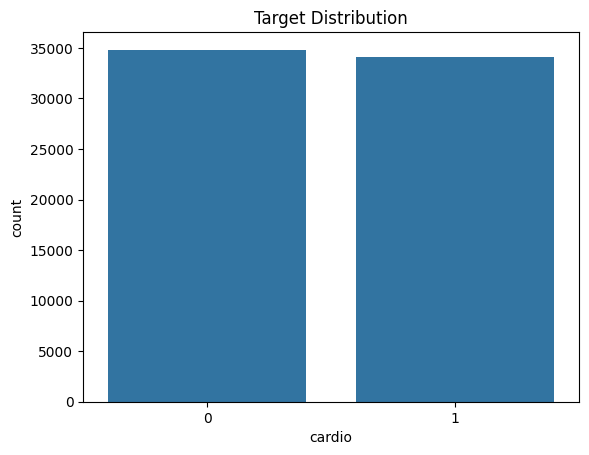

In [21]:
sns.countplot(x='cardio', data=df)
plt.title("Target Distribution")
plt.show()

# # cheak correlation for all columns 

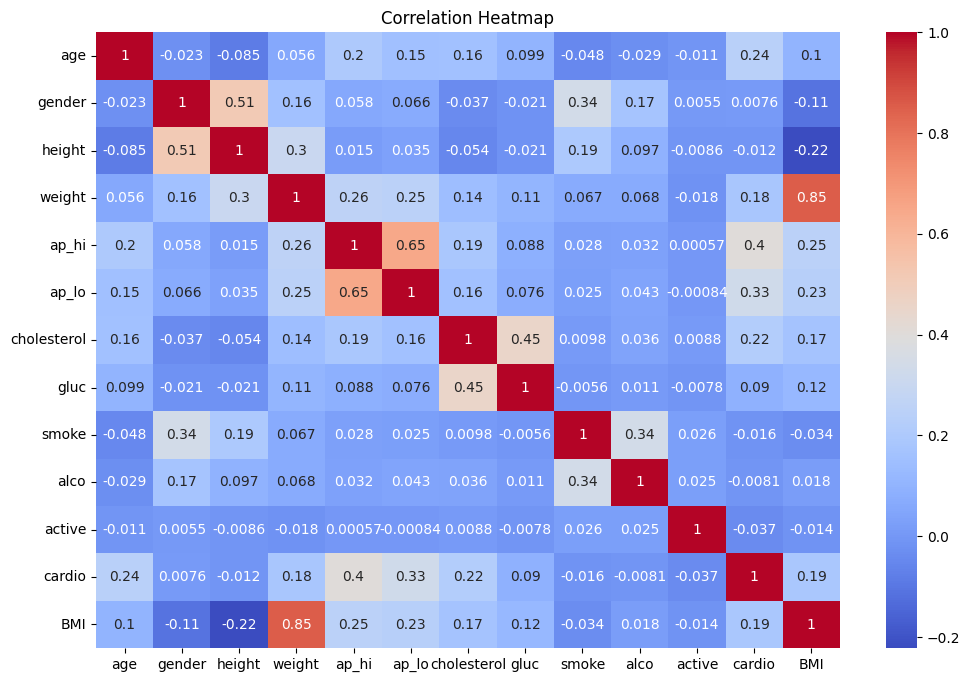

In [22]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

# # sns.histplot() is used to visualize the distribution of numerical data (continuous values) using a histogram.

**age vs heart Disease histogram**

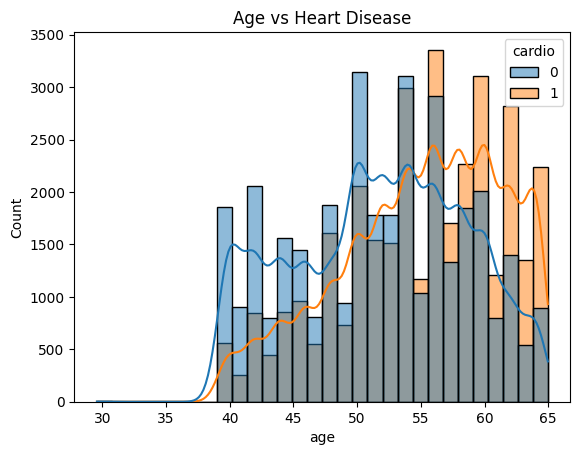

In [23]:
sns.histplot(data=df, x='age', hue='cardio', bins=30, kde=True)
plt.title("Age vs Heart Disease")
plt.show()

# #sns.scatterplot() is used to visualize the relationship between two numerical variables 

**Blood Pressure vs Disease**

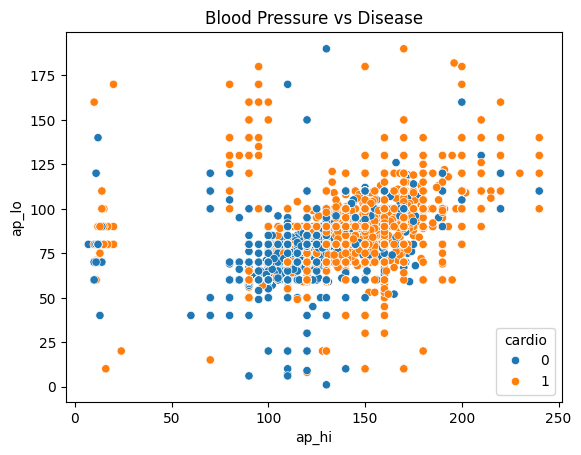

In [24]:
sns.scatterplot(x='ap_hi', y='ap_lo', hue='cardio', data=df)
plt.title("Blood Pressure vs Disease")
plt.show()

# # sns.countplot() is used to count how many times each category appears in a dataset and display it as a bar chart.

**cholesterol vs Diseases**

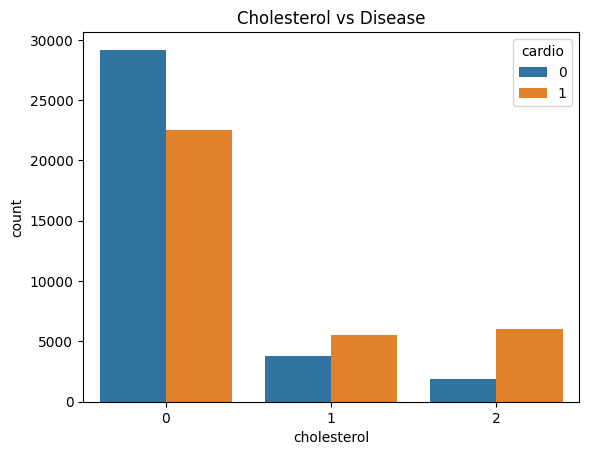

In [25]:
sns.countplot(x='cholesterol', hue='cardio', data=df)
plt.title("Cholesterol vs Disease")
plt.show()

**Smoking vs Disease**

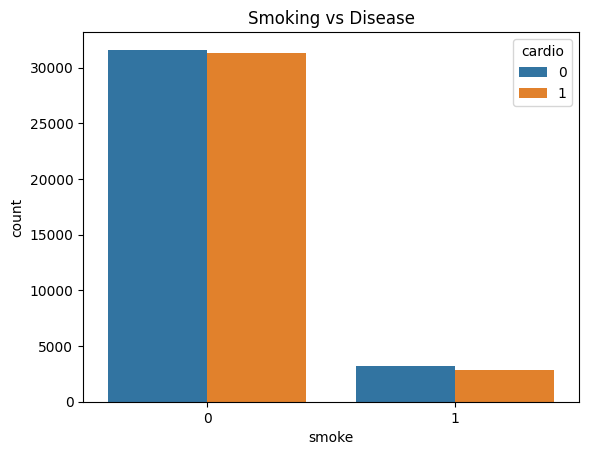

In [26]:
sns.countplot(x='smoke', hue='cardio', data=df)
plt.title("Smoking vs Disease")
plt.show()

# #sns.boxplot() is used to visualize the distribution of numerical data and detect outliers

It shows a box-and-whisker plot 

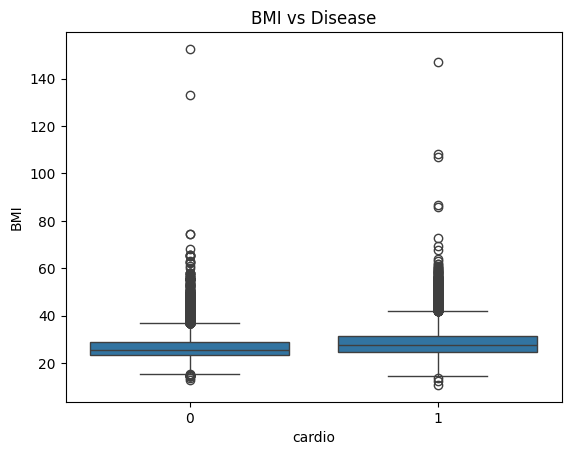

In [27]:
sns.boxplot(x='cardio', y='BMI', data=df)
plt.title("BMI vs Disease")
plt.show()

# # split data into train and test  

**drop cardio columns in x because cardio is target columns so data leakage problem **

In [28]:
from sklearn.model_selection import train_test_split
x=df.drop('cardio', axis=1)
y=df['cardio']
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42)


# # feature scalling using standardlization

**"fit_transform()" is used on training data to learn scaling parameters (mean, std) and apply transformation.**

**"transform()" is used on test data to apply the same scaling without learning again (to avoid data leakage).**

In [29]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

# # Learn 3 different model 

**train logisticRegegression model**

In [30]:
from sklearn.linear_model import LogisticRegression
logistic=LogisticRegression()
logistic.fit(x_train_scaled, y_train)

y_pred_logistic = logistic.predict(x_test_scaled)

**train RandomForestClassifier**

*randomForest does not need scalling*

In [31]:
from sklearn.ensemble import RandomForestClassifier
random_forest = RandomForestClassifier()
random_forest.fit(x_train, y_train)
y_pred_random_forest = random_forest.predict(x_test)

**Train SVC model**

In [32]:
from sklearn.svm import SVC

svm = SVC()
svm.fit(x_train_scaled, y_train)

y_pred_svm = svm.predict(x_test_scaled)

# # compare 3 model accuracy score 

In [33]:
from sklearn.metrics import accuracy_score

print("Logistic:", accuracy_score(y_test, y_pred_logistic))
print("Random Forest:", accuracy_score(y_test, y_pred_random_forest))
print("SVM:", accuracy_score(y_test, y_pred_svm))

Logistic: 0.7247081006599463
Random Forest: 0.709406048299369
SVM: 0.732250344477482


# # cheak all 3 model classification_report for cheak precision and recall 

In [34]:
from sklearn.metrics import classification_report


In [35]:
print(classification_report(y_test, y_pred_logistic))


              precision    recall  f1-score   support

           0       0.70      0.78      0.74      6908
           1       0.75      0.67      0.71      6881

    accuracy                           0.72     13789
   macro avg       0.73      0.72      0.72     13789
weighted avg       0.73      0.72      0.72     13789



In [36]:
print(classification_report(y_test, y_pred_random_forest))

              precision    recall  f1-score   support

           0       0.71      0.72      0.71      6908
           1       0.71      0.70      0.71      6881

    accuracy                           0.71     13789
   macro avg       0.71      0.71      0.71     13789
weighted avg       0.71      0.71      0.71     13789



In [37]:
print(classification_report(y_test, y_pred_svm))

              precision    recall  f1-score   support

           0       0.71      0.79      0.75      6908
           1       0.76      0.68      0.72      6881

    accuracy                           0.73     13789
   macro avg       0.74      0.73      0.73     13789
weighted avg       0.74      0.73      0.73     13789



# # confussion matrix for all 3 model 

In [38]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

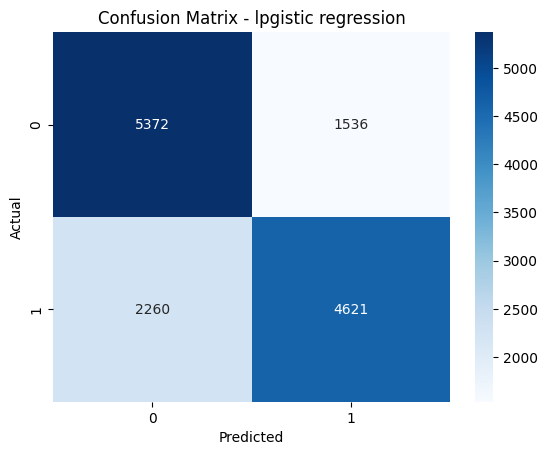

In [39]:
cm = confusion_matrix(y_test, y_pred_logistic)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - lpgistic regression")
plt.show()

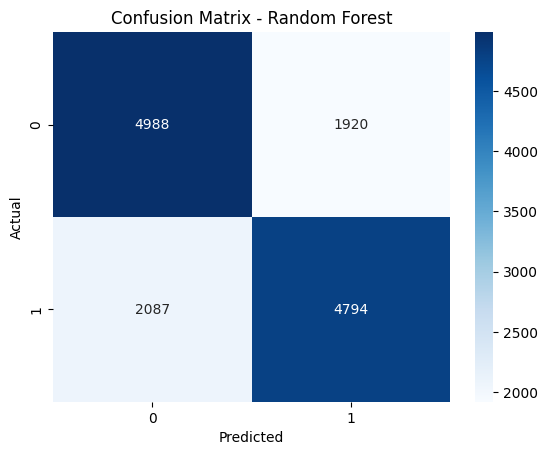

In [40]:
cm = confusion_matrix(y_test, y_pred_random_forest)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Random Forest")
plt.show()

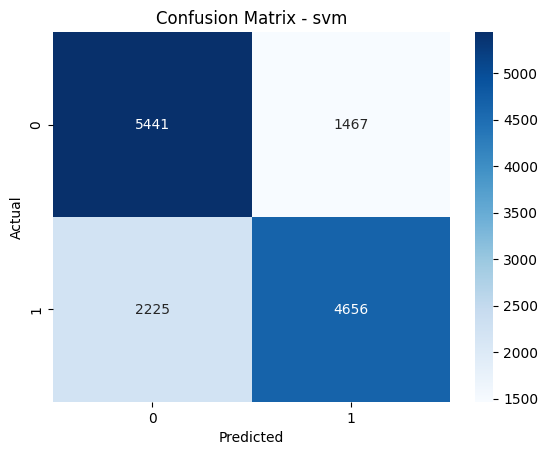

In [41]:
cm = confusion_matrix(y_test, y_pred_svm)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - svm")
plt.show()

# # So Random_forest is good model compare to other model


ROC CURVE

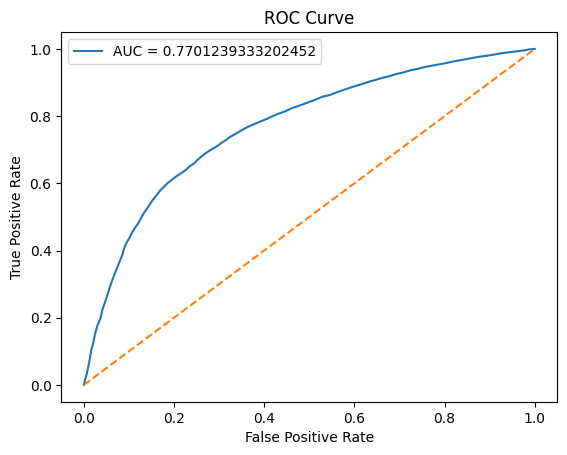

In [42]:
from sklearn.metrics import roc_curve, auc

y_prob = random_forest.predict_proba(x_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label="AUC = " + str(roc_auc))
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

# #HYPERPARAMETER TUNNING 

In [43]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

rf = RandomForestClassifier(random_state=42)

grid = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=3,
    n_jobs=-1,
    verbose=2
)
grid.fit(x_train, y_train)

Fitting 3 folds for each of 24 candidates, totalling 72 fits


GridSearchCV(cv=3, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [5, 10, 20], 'min_samples_leaf': [1, 2],
                         'min_samples_split': [2, 5],
                         'n_estimators': [100, 200]},
             verbose=2)

***print best parameter*** 

In [44]:
print(grid.best_params_)

{'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}


In [45]:
best_rf = grid.best_estimator_

y_pred_best = best_rf.predict(x_test)

# #ACCURACY CHEAK AGAIN 

In [46]:
from sklearn.metrics import accuracy_score

print("Tuned RF:", accuracy_score(y_test, y_pred_best))

Tuned RF: 0.7337007759808543


# # draw graph for feature_importance 

In [47]:
feature_importance = pd.Series(
    best_rf.feature_importances_,
    index=x.columns
).sort_values(ascending=False)

print(feature_importance)

ap_hi          0.428422
ap_lo          0.195281
age            0.143111
cholesterol    0.086006
BMI            0.053068
weight         0.038272
height         0.023497
gluc           0.012204
active         0.007966
smoke          0.004563
gender         0.003883
alco           0.003726
dtype: float64


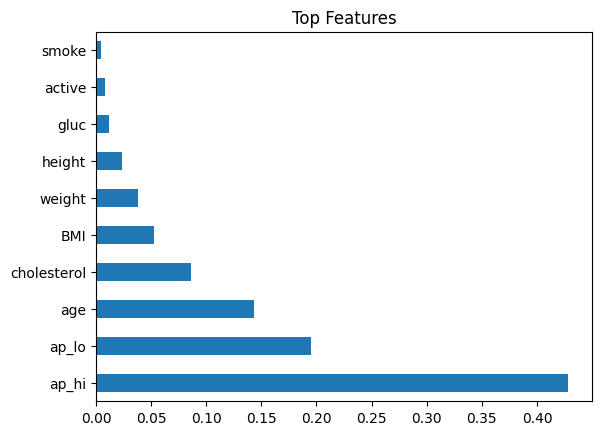

[CV] END max_depth=5, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   3.3s
[CV] END max_depth=5, min_samples_leaf=1, min_samples_split=5, n_estimators=100; total time=   3.0s
[CV] END max_depth=5, min_samples_leaf=1, min_samples_split=5, n_estimators=100; total time=   3.1s
[CV] END max_depth=5, min_samples_leaf=2, min_samples_split=2, n_estimators=100; total time=   3.2s
[CV] END max_depth=5, min_samples_leaf=2, min_samples_split=2, n_estimators=100; total time=   3.0s
[CV] END max_depth=5, min_samples_leaf=2, min_samples_split=2, n_estimators=200; total time=   6.3s
[CV] END max_depth=5, min_samples_leaf=2, min_samples_split=5, n_estimators=200; total time=   6.2s
[CV] END max_depth=10, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   5.7s
[CV] END max_depth=10, min_samples_leaf=1, min_samples_split=5, n_estimators=100; total time=   5.6s
[CV] END max_depth=10, min_samples_leaf=1, min_samples_split=5, n_estimators=100; total time=   5.

In [48]:
feature_importance.head(10).plot(kind='barh')
plt.title("Top Features")
plt.show()

# ##NOTEBOOK IS COMPLETED  